In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(file_path):
    """Load dataset from CSV file"""
    df = pd.read_csv('/content/Final_Dataset.csv')
    print(f"Initial data shape: {df.shape}")
    return df

def clean_data(df):
    """Perform data cleaning operations"""
    # Handle missing values
    print("\nMissing values before cleaning:")
    print(df.isnull().sum())

    # Fill or drop missing values based on columns
    df['CoC Category'] = df['CoC Category'].fillna('Unknown')
    df['Count Types'] = df['Count Types'].fillna('Not Specified')

    # Drop rows with missing critical numeric values
    df = df.dropna(subset=['Count'])

    # Convert count to integer
    df['Count'] = pd.to_numeric(df['Count'], errors='coerce').astype('Int64')

    print("\nMissing values after cleaning:")
    print(df.isnull().sum())
    return df

def perform_eda(df):
    """Perform exploratory data analysis"""
    # Basic statistics
    print("\nSummary Statistics:")
    print(df.describe())

    # Value counts for categorical columns
    print("\nCoC Categories Distribution:")
    print(df['CoC Category'].value_counts())

    # Time series analysis (if applicable)
    if 'Year' in df.columns:
        plt.figure(figsize=(12,6))
        sns.lineplot(x='Year', y='Count', data=df, estimator='sum')
        plt.title('Total Homeless Count Over Time')
        plt.show()

    # Distribution of counts
    plt.figure(figsize=(12,6))
    sns.histplot(df['Count'], bins=50, kde=True)
    plt.title('Distribution of Homeless Counts')
    plt.show()

    # Top 10 CoCs by total count
    top_cocs = df.groupby('CoC Name')['Count'].sum().nlargest(10)
    plt.figure(figsize=(12,6))
    top_cocs.plot(kind='barh')
    plt.title('Top 10 CoCs by Total Homeless Count')
    plt.xlabel('Total Count')
    plt.show()

if __name__ == "__main__":
    # Example usage
    df = load_data('final_dataset.csv')
    cleaned_df = clean_data(df)
    perform_eda(cleaned_df)
    cleaned_df.to_csv('cleaned_homelessness_data.csv', index=False)

Initial data shape: (6524, 20)

Missing values before cleaning:
Total Population                                     0
Median Gross Rent                                    0
Median Household Income                              0
Poverty_Rate                                         0
Vacancy_Rate                                         0
Renter_Household_Rate                                0
Cost_Burdened_Rate                                   0
Unemployment_Rate                                    0
Total Year-Round Beds (ES, TH, SH)                2747
Average Temperature                                102
Overall Homeless                                   144
Overall Homeless Individuals                       144
Overall Homeless People in Families                144
Unsheltered Homeless                               144
Sheltered Total Homeless                           144
Overall_Homeless_Per_Capita                        144
Overall_Homeless_Individuals_Per_Capita            144
O

KeyError: 'CoC Category'

In [2]:
print("Initial dataset shape:", df.shape)
print(df.info())
print(df.describe())

Initial dataset shape: (6524, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6524 entries, 0 to 6523
Data columns (total 20 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Total Population                                6524 non-null   int64  
 1   Median Gross Rent                               6524 non-null   int64  
 2   Median Household Income                         6524 non-null   int64  
 3   Poverty_Rate                                    6524 non-null   float64
 4   Vacancy_Rate                                    6524 non-null   float64
 5   Renter_Household_Rate                           6524 non-null   float64
 6   Cost_Burdened_Rate                              6524 non-null   float64
 7   Unemployment_Rate                               6524 non-null   float64
 8   Total Year-Round Beds (ES, TH, SH)              3777 non-null   float64
 9   Average

In [4]:
import numpy as np

# a. Remove duplicate rows
df.drop_duplicates(inplace=True)
print("Shape after dropping duplicates:", df.shape)

# b. Handling missing values

# For numeric columns: fill missing values with the median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

# For categorical columns: fill missing values with the mode
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
    df[col].fillna(mode_val, inplace=True)

# Verify missing values have been handled
print("Missing values after cleaning:")
print(df.isnull().sum())


Shape after dropping duplicates: (6517, 20)
Missing values after cleaning:
Total Population                                  0
Median Gross Rent                                 0
Median Household Income                           0
Poverty_Rate                                      0
Vacancy_Rate                                      0
Renter_Household_Rate                             0
Cost_Burdened_Rate                                0
Unemployment_Rate                                 0
Total Year-Round Beds (ES, TH, SH)                0
Average Temperature                               0
Overall Homeless                                  0
Overall Homeless Individuals                      0
Overall Homeless People in Families               0
Unsheltered Homeless                              0
Sheltered Total Homeless                          0
Overall_Homeless_Per_Capita                       0
Overall_Homeless_Individuals_Per_Capita           0
Overall_Homeless_People_in_Families_Per_C

<ipython-input-4-6a49b894f448>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


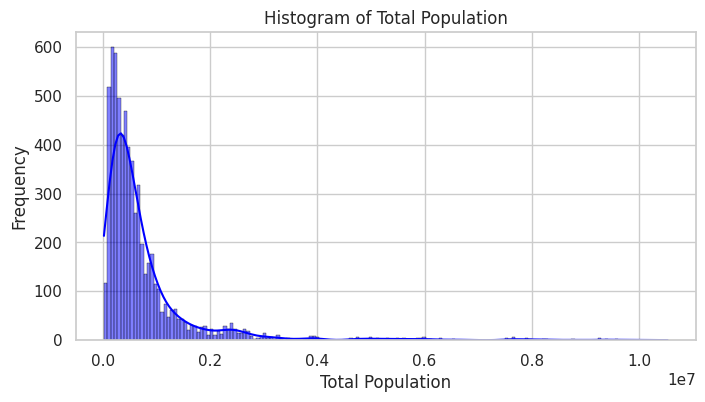

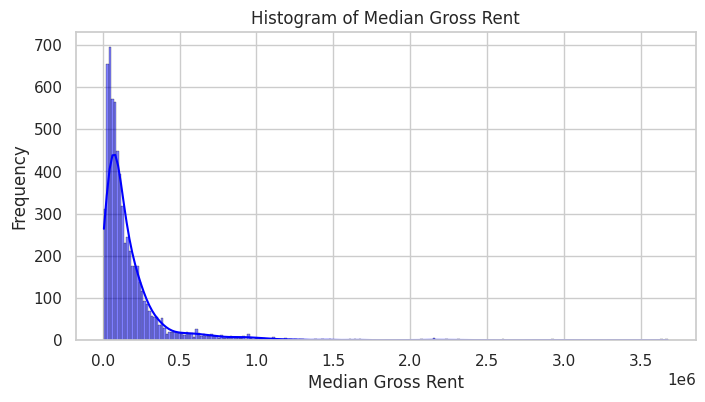

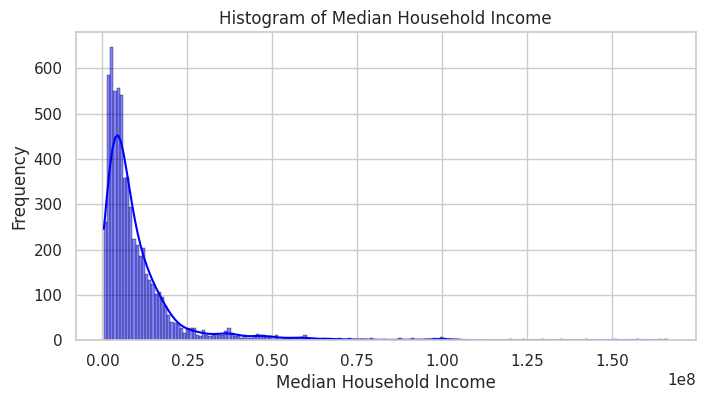

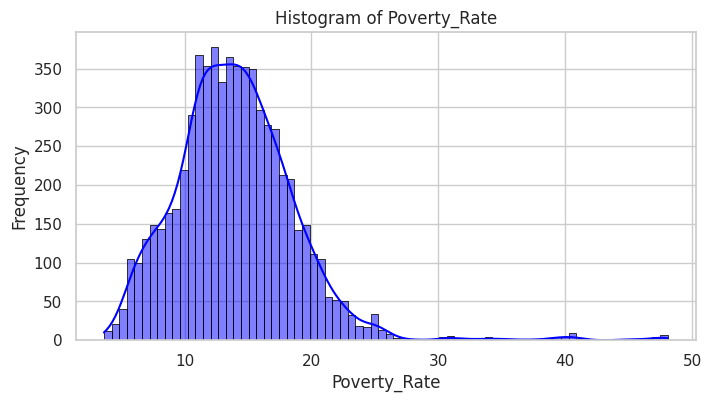

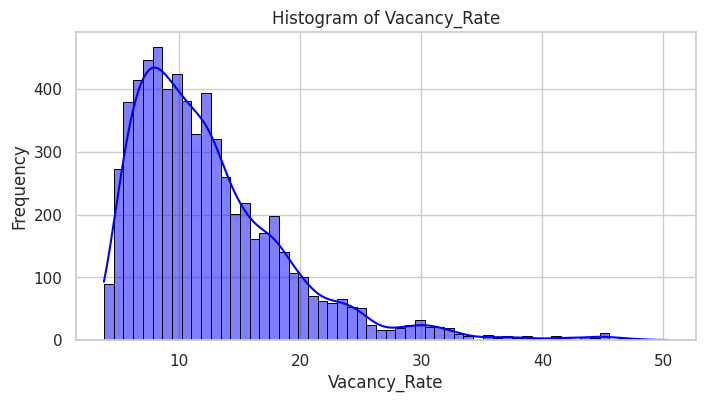

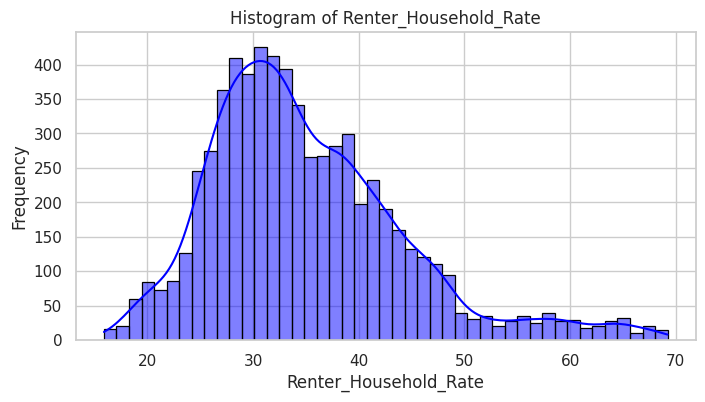

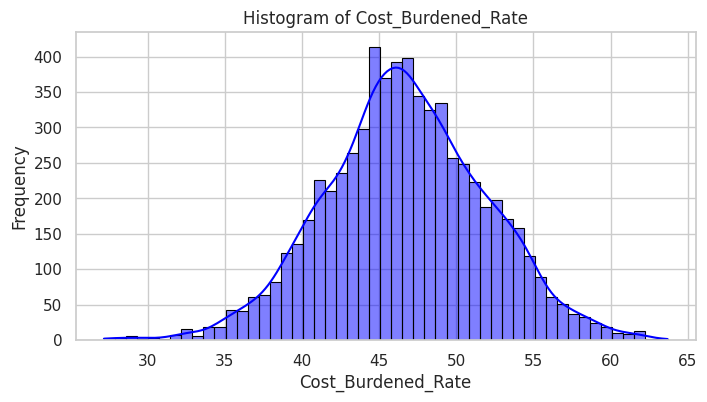

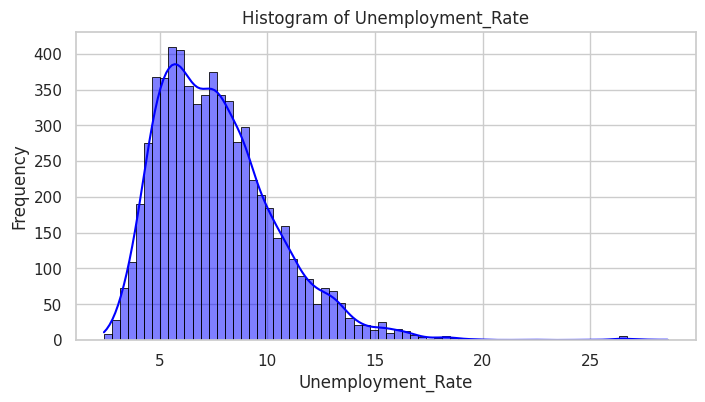

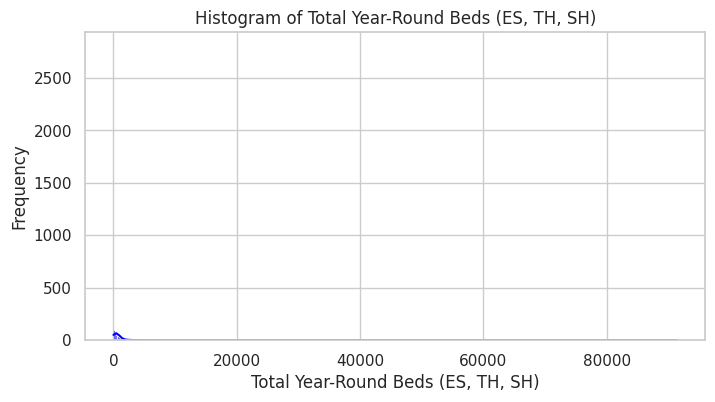

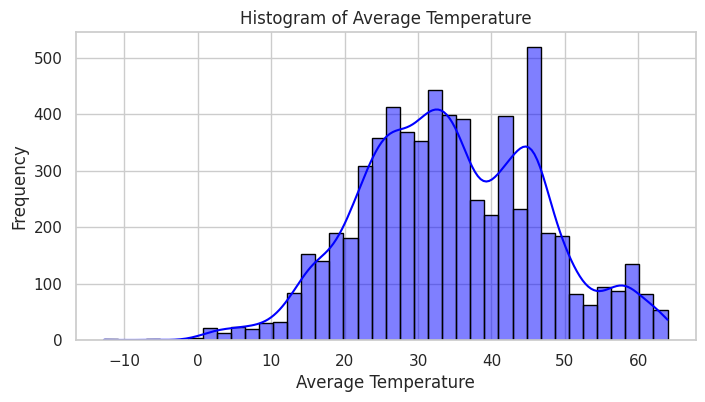

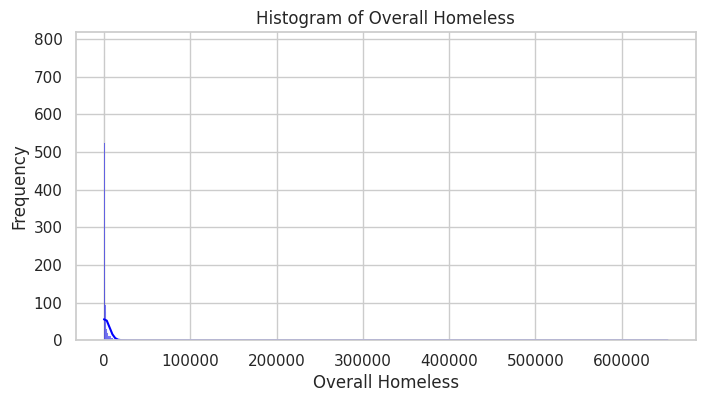

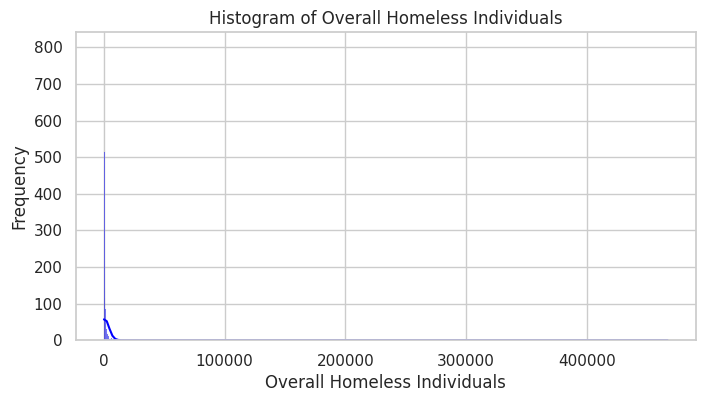

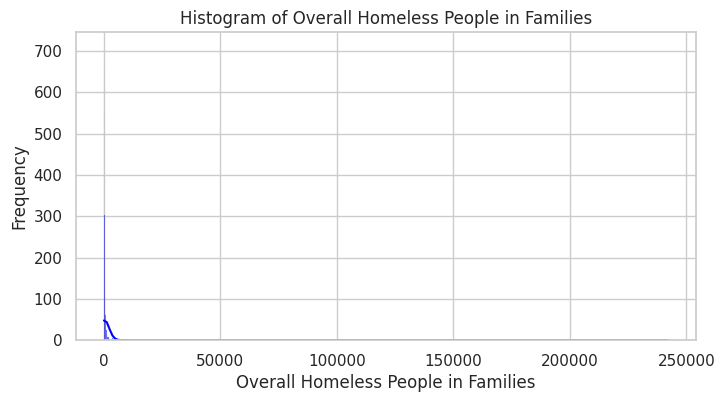

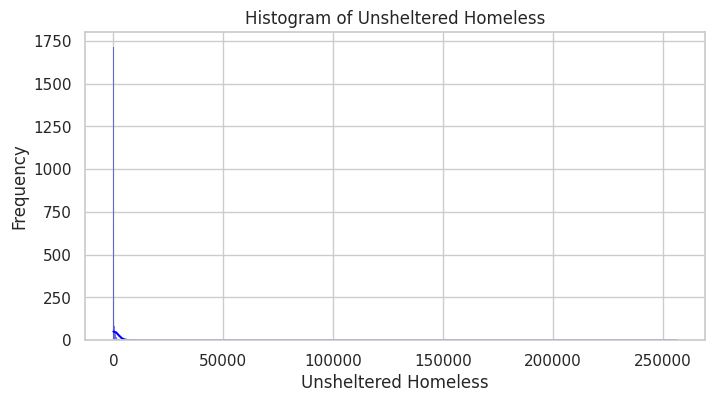

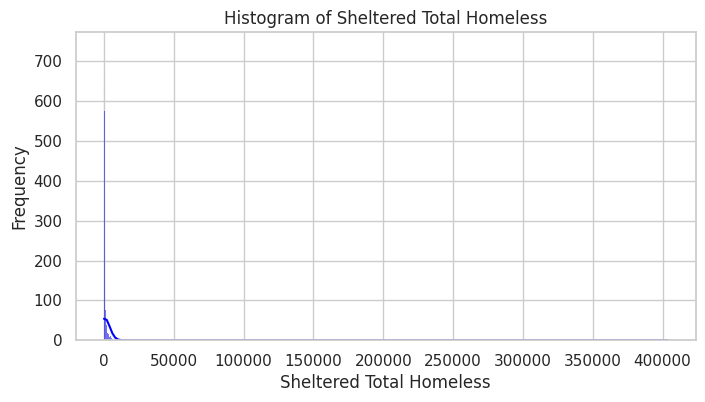

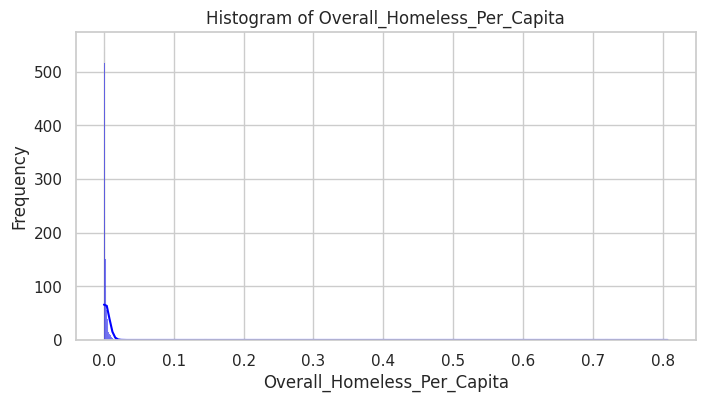

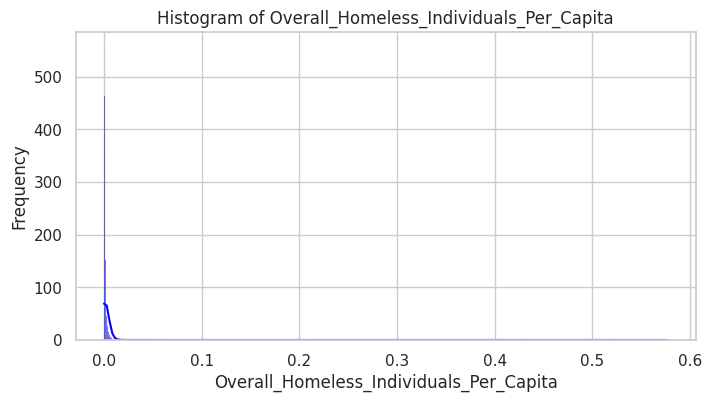

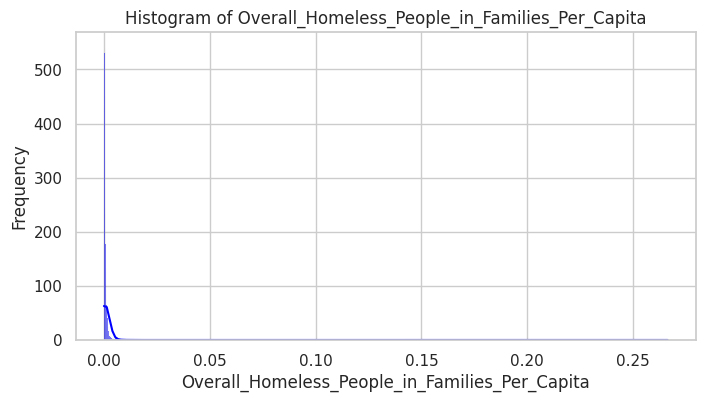

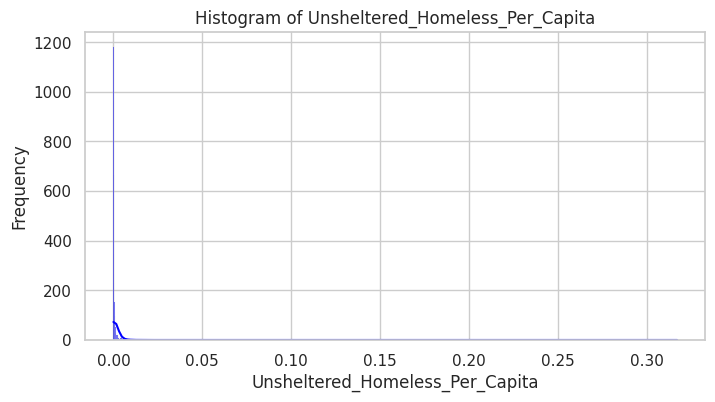

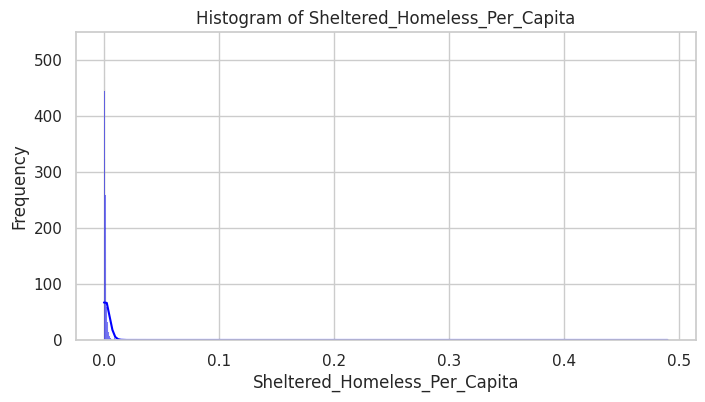

In [5]:
# Set a common style for plots
sns.set(style="whitegrid")

# a. Histograms for each numeric column
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, color='blue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


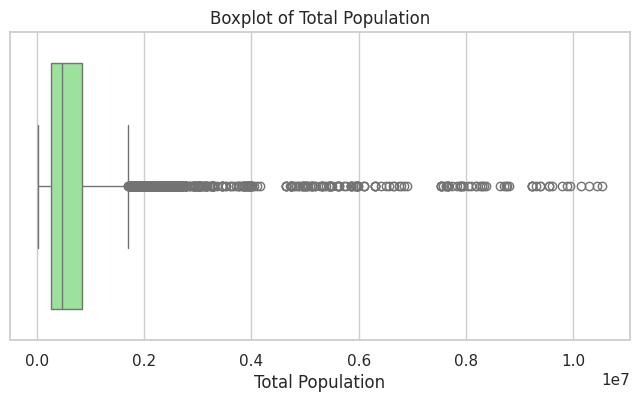

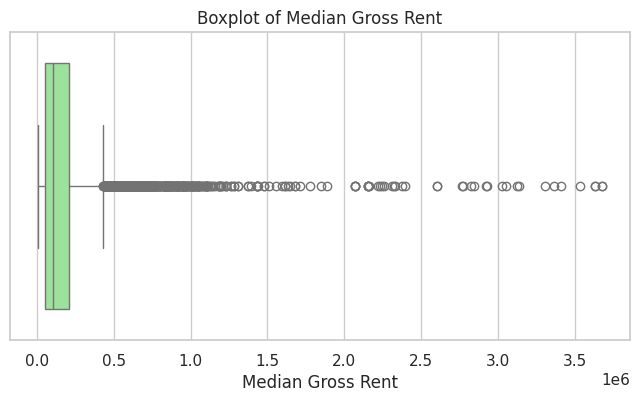

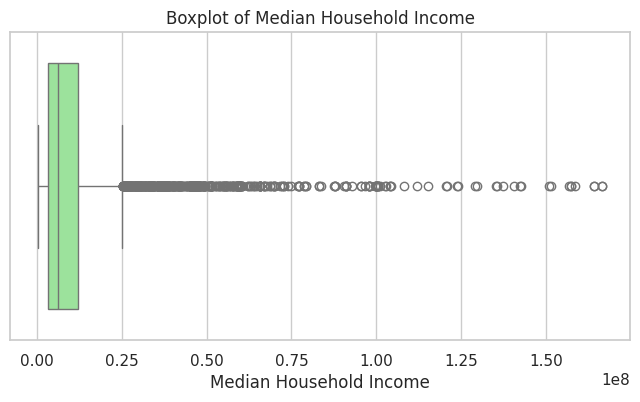

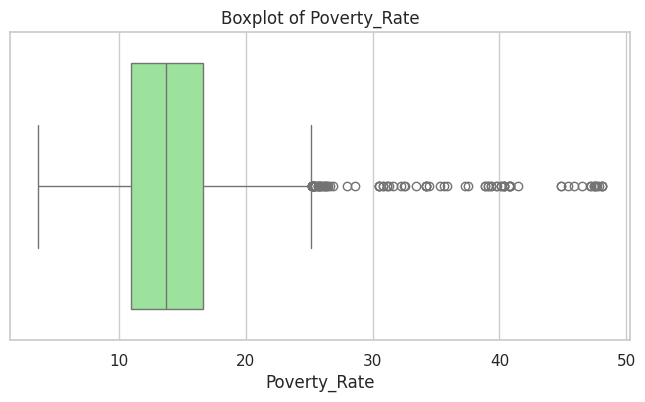

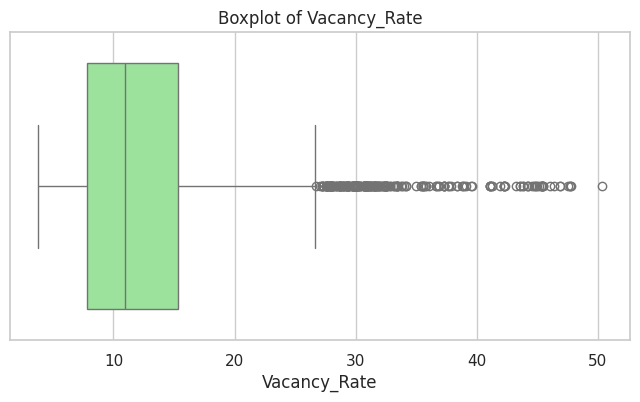

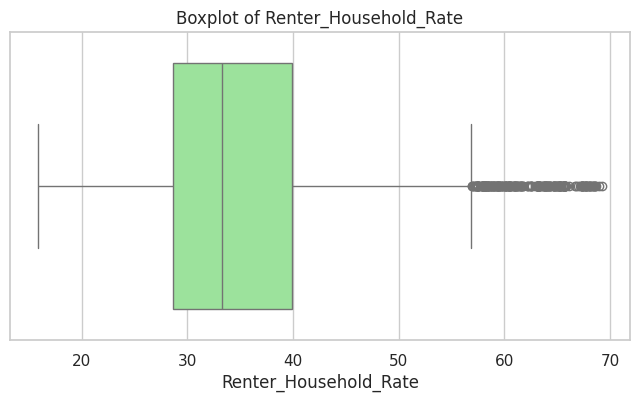

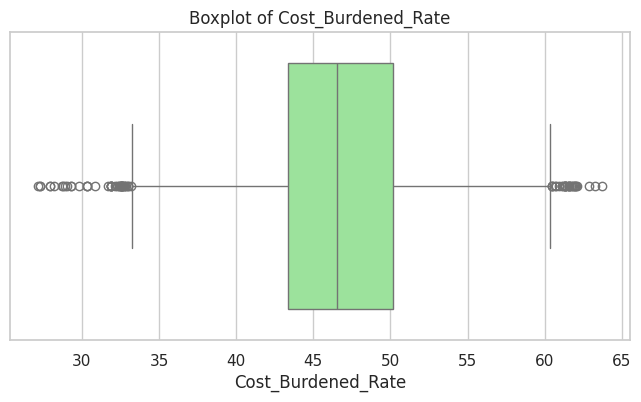

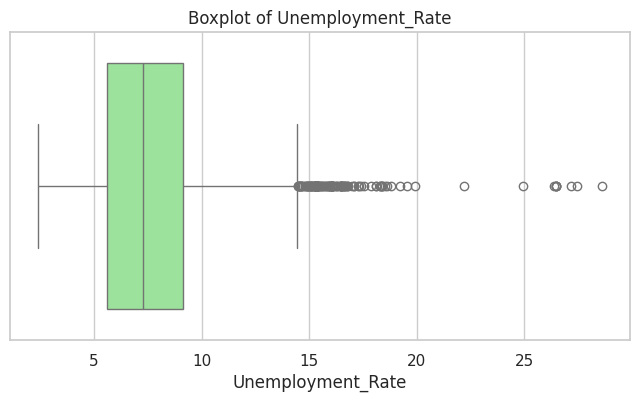

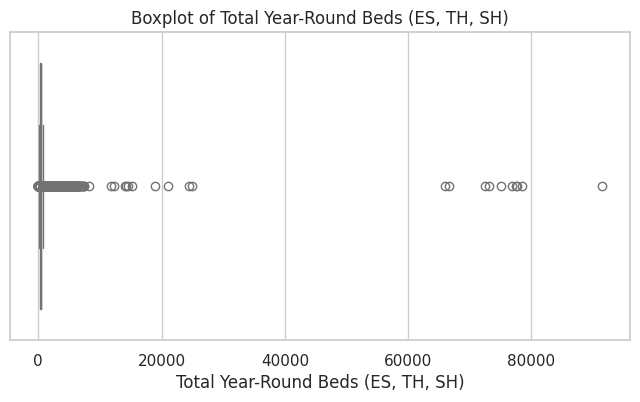

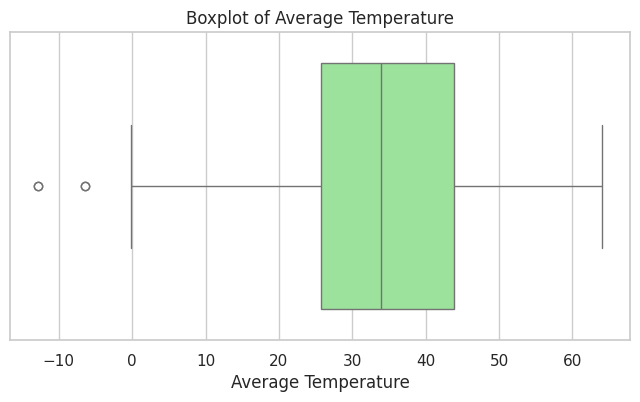

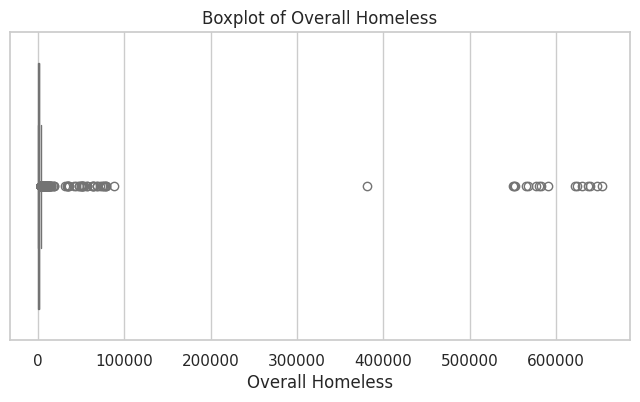

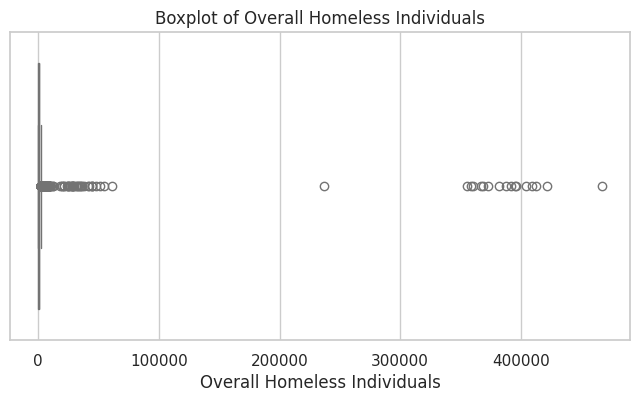

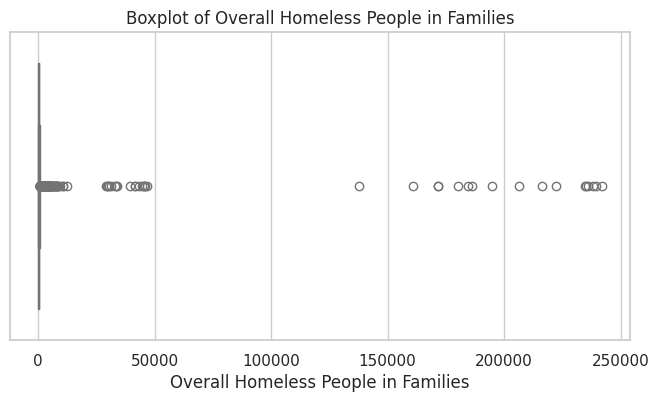

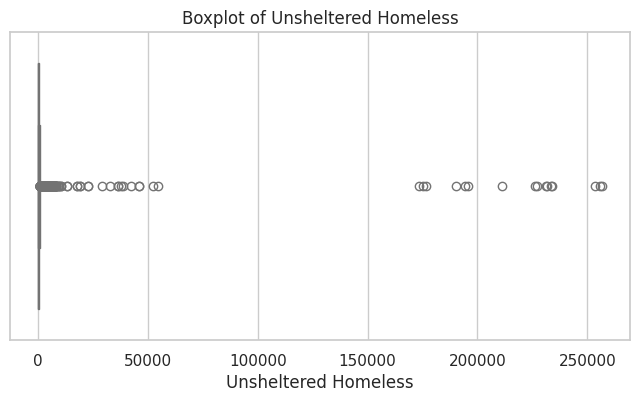

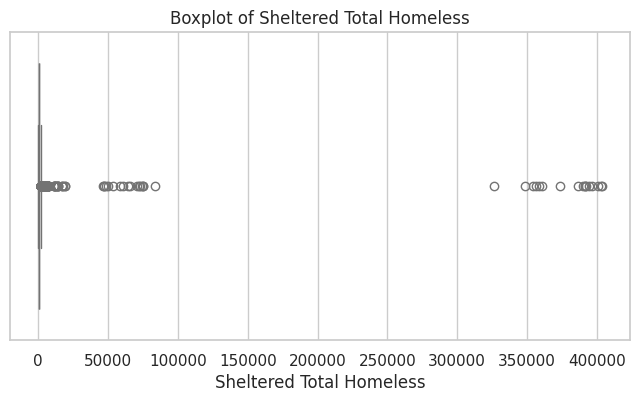

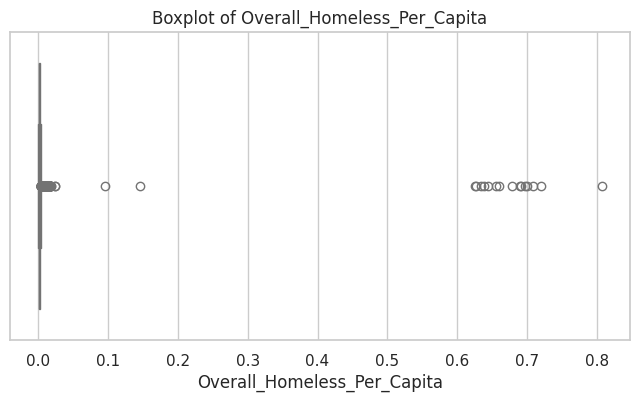

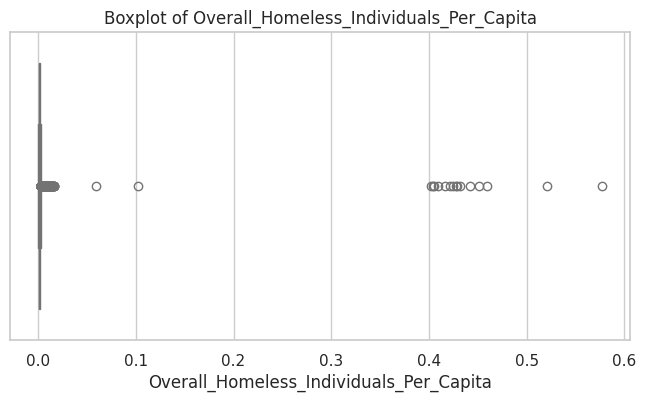

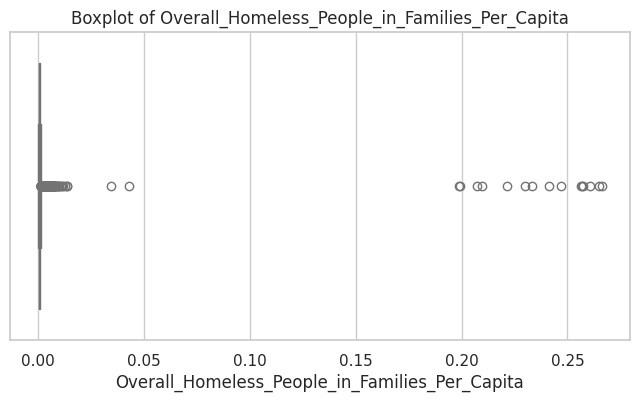

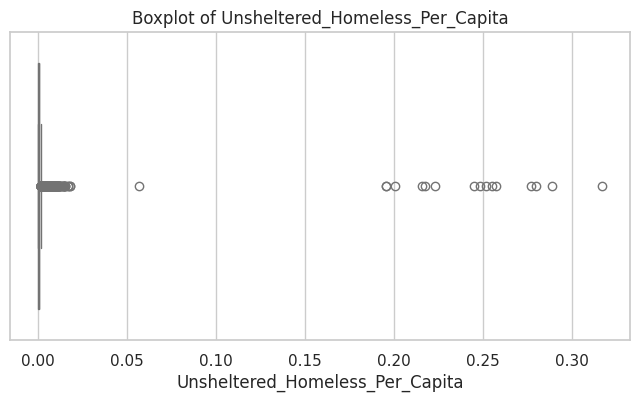

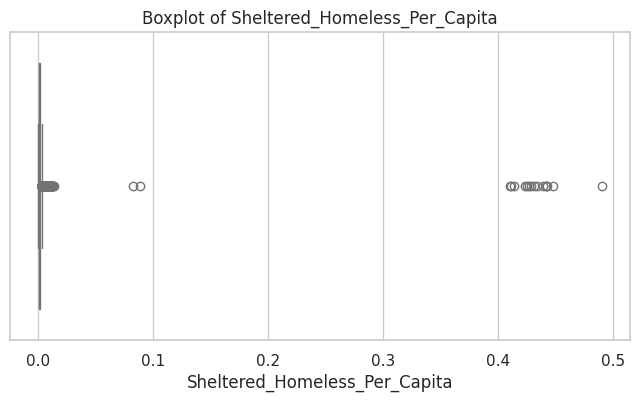

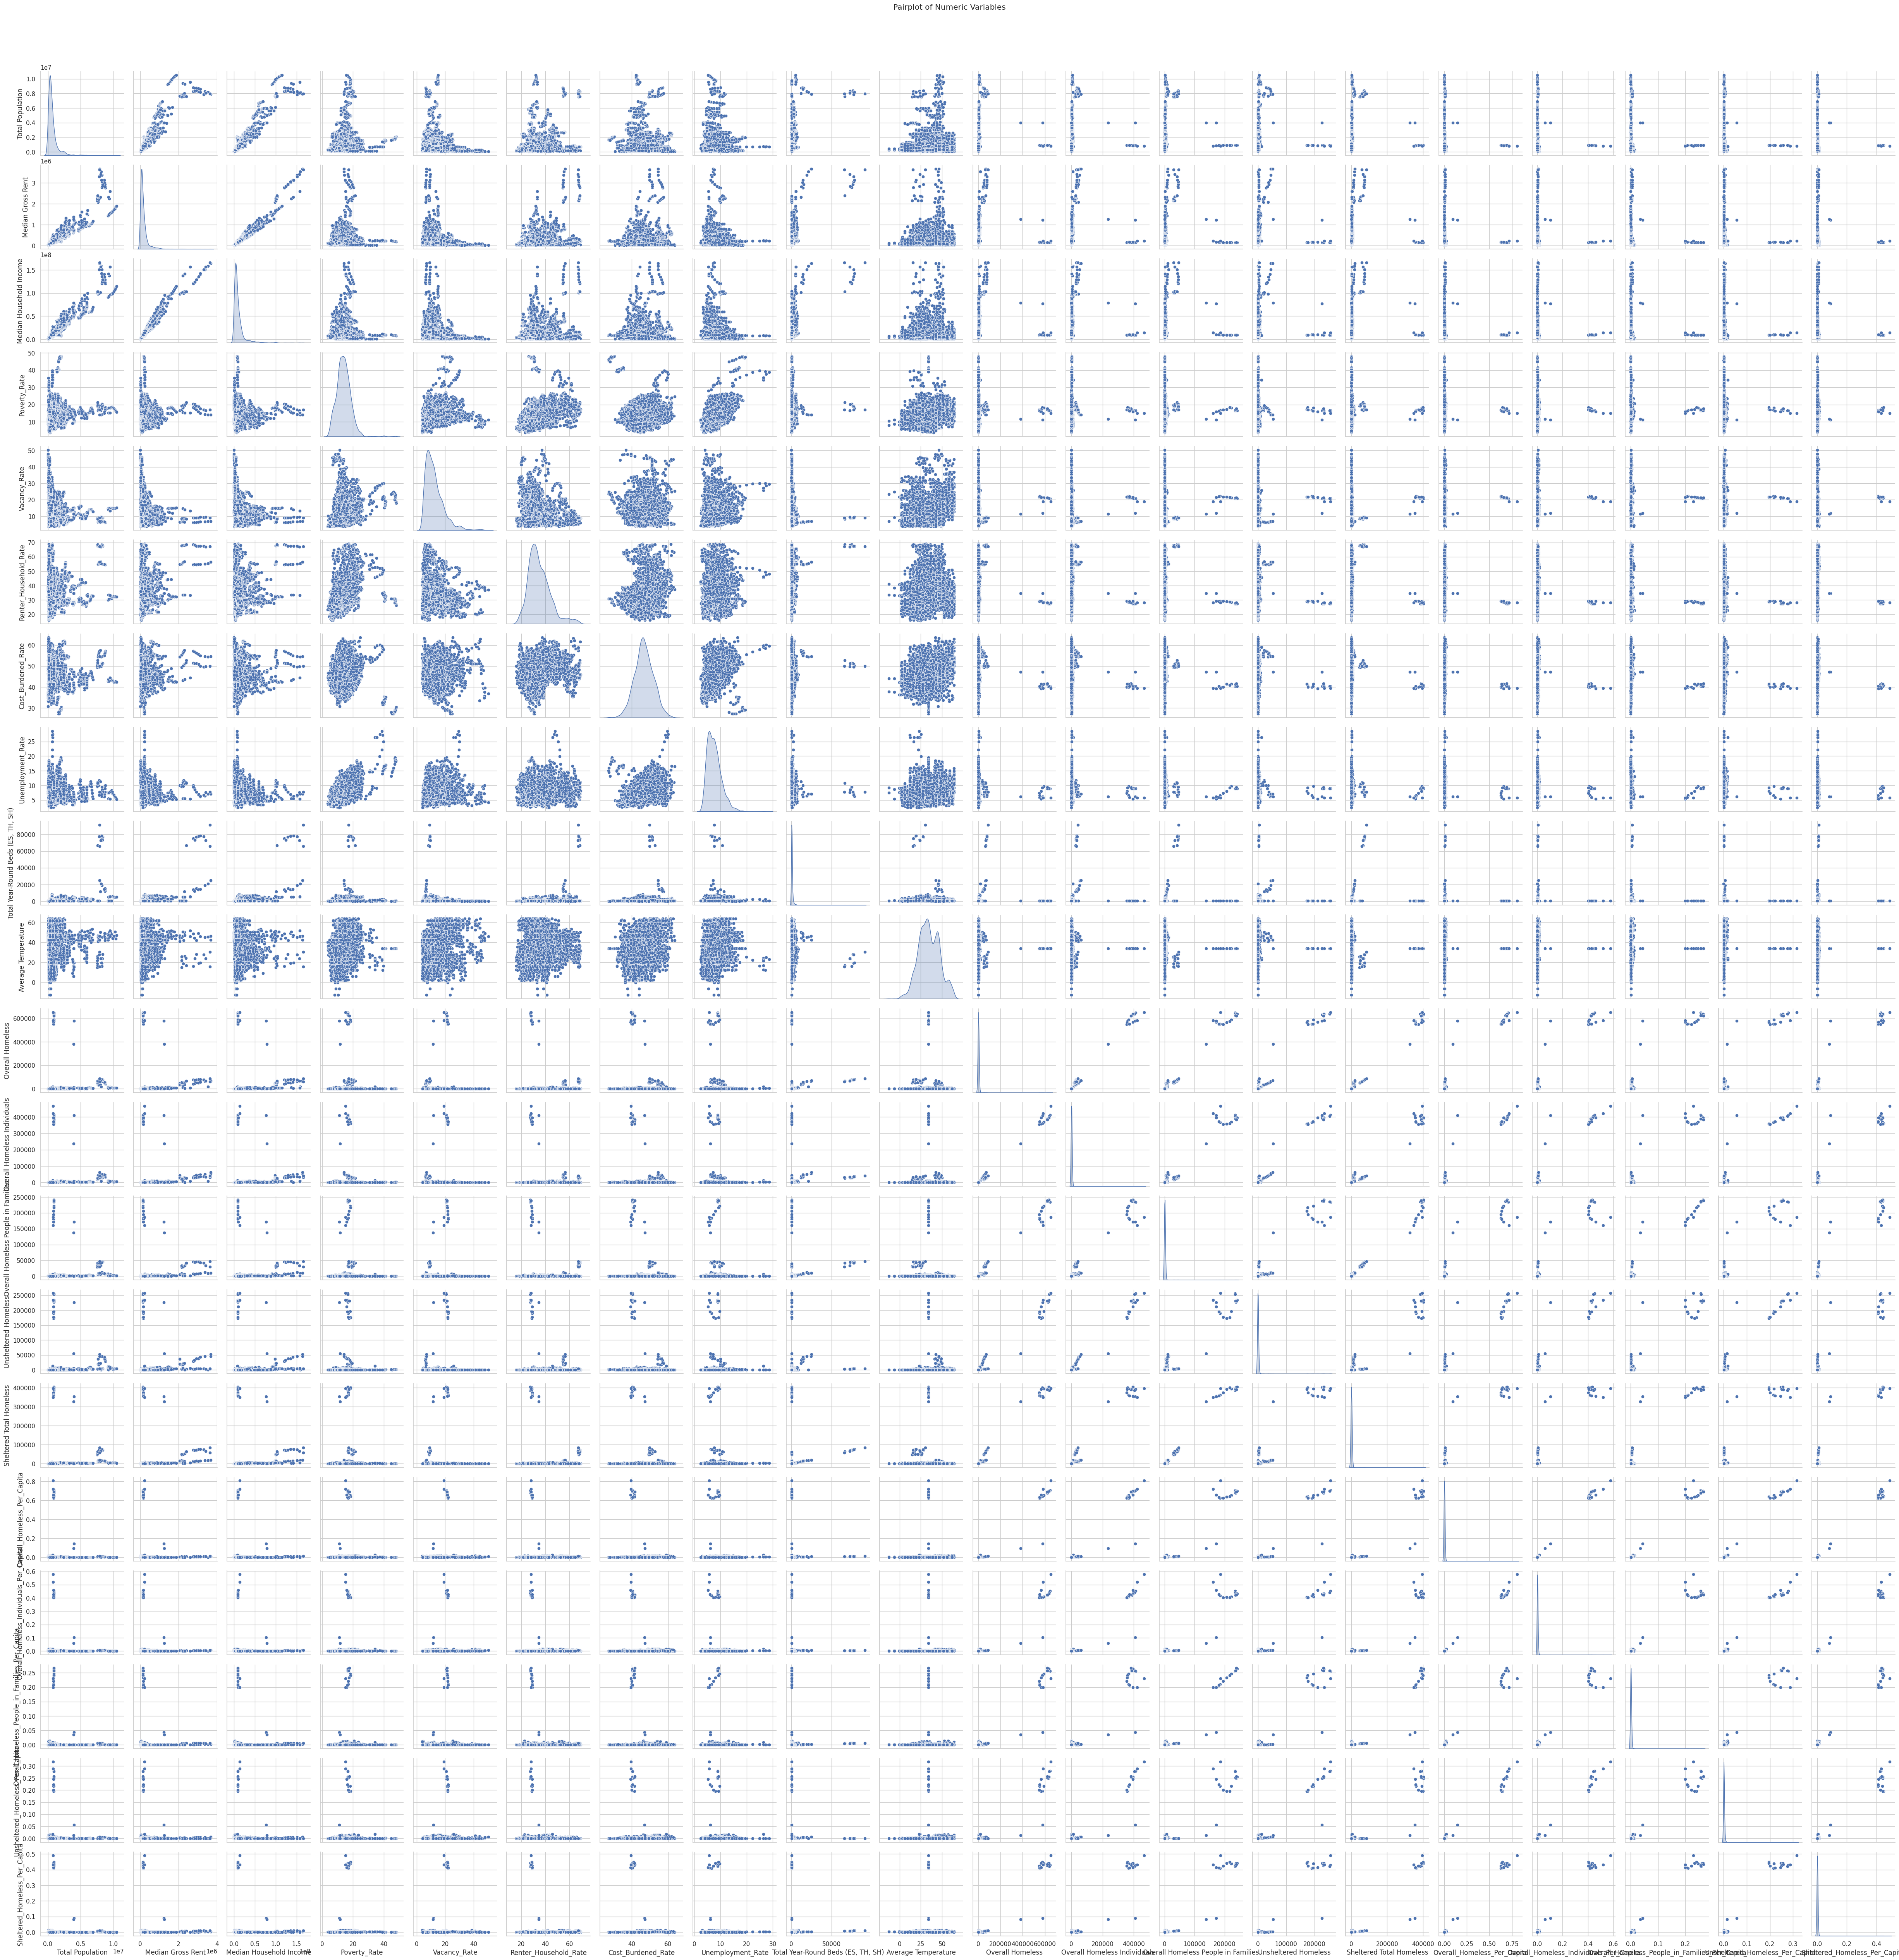

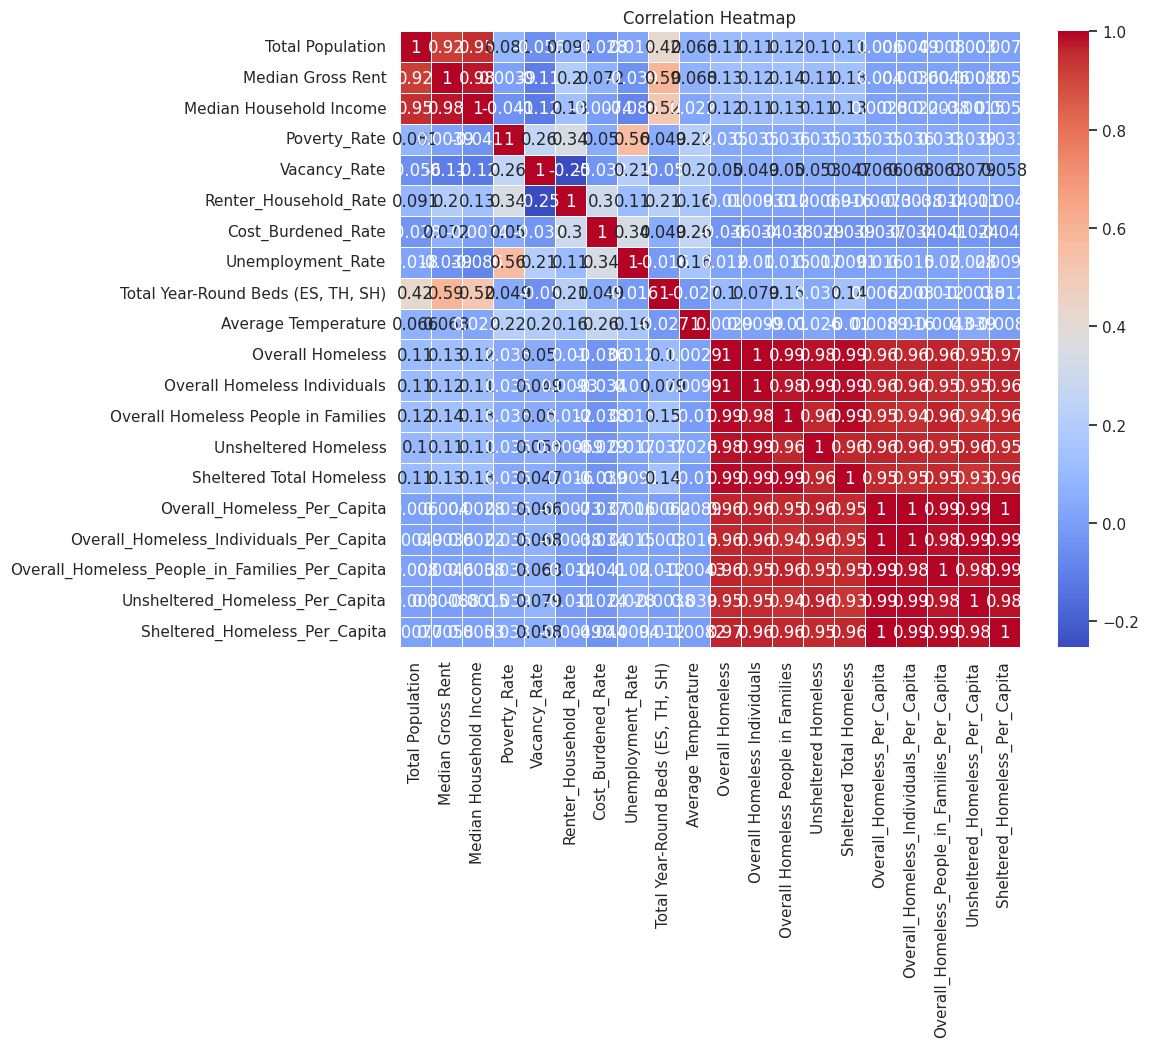

In [6]:
# b. Boxplots for each numeric column to check for outliers
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

# c. Countplots for each categorical column
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, palette='pastel')
    plt.title(f'Countplot of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

# d. Pairplot for numeric columns (if more than one numeric column exists)
if len(num_cols) >= 2:
    sns.pairplot(df[num_cols], diag_kind="kde")
    plt.suptitle('Pairplot of Numeric Variables', y=1.02)
    plt.show()

# e. Correlation Heatmap for numeric columns
plt.figure(figsize=(10, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Top 15 variables with the highest overall correlation:
['Overall Homeless', 'Overall Homeless People in Families', 'Sheltered Total Homeless', 'Overall Homeless Individuals', 'Unsheltered Homeless', 'Overall_Homeless_Per_Capita', 'Sheltered_Homeless_Per_Capita', 'Overall_Homeless_People_in_Families_Per_Capita', 'Overall_Homeless_Individuals_Per_Capita', 'Unsheltered_Homeless_Per_Capita', 'Median Gross Rent', 'Median Household Income', 'Total Population', 'Total Year-Round Beds (ES, TH, SH)', 'Poverty_Rate']


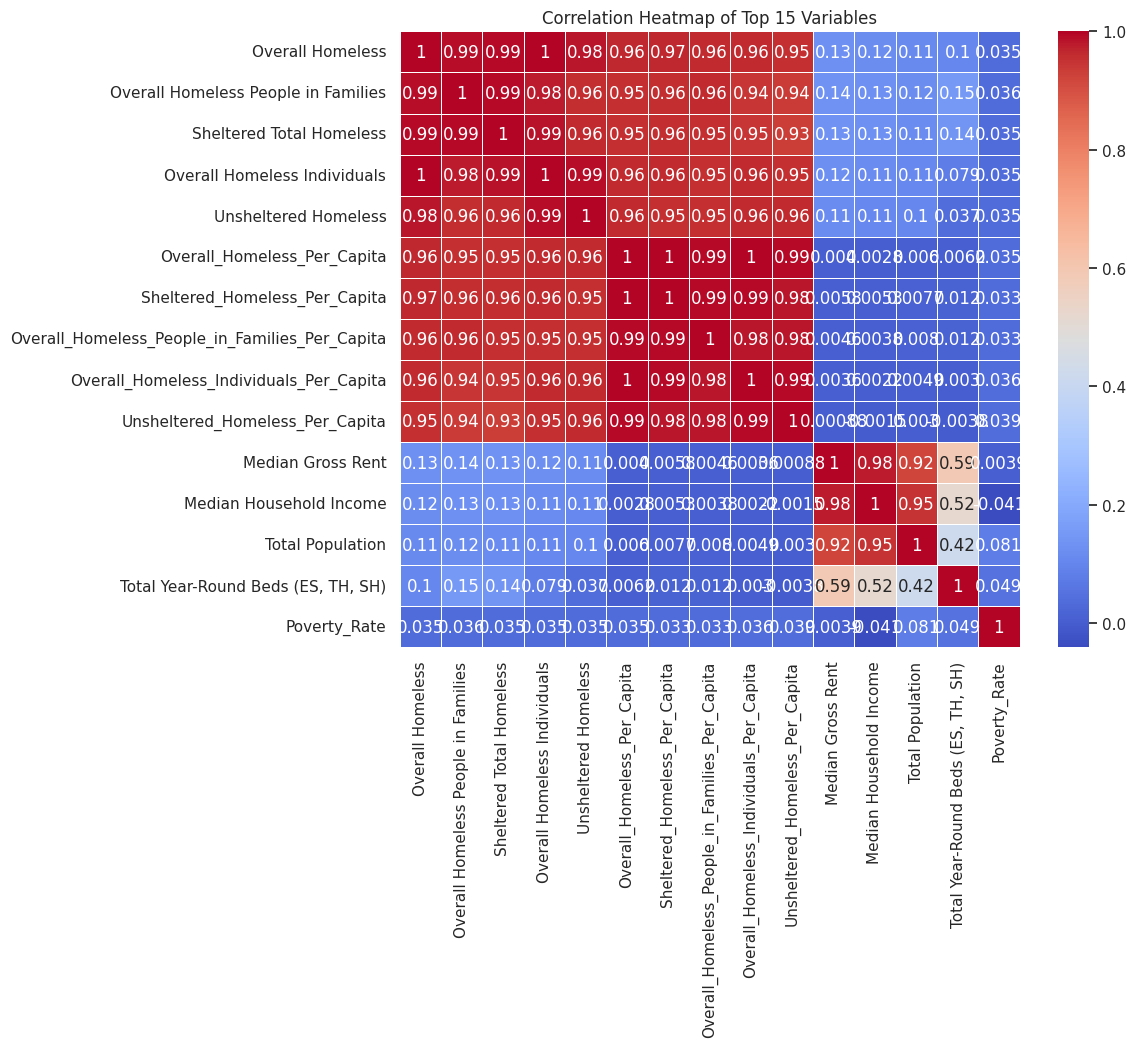

In [9]:


# Assume that data cleaning has already been done
# Extract only numeric columns for correlation analysis
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# -------------------------------
# 2. Compute the Correlation Matrix
# -------------------------------
corr_matrix = df[num_cols].corr()

# To avoid counting self-correlation, set the diagonal to zero
corr_matrix_no_diag = corr_matrix.copy()
np.fill_diagonal(corr_matrix_no_diag.values, 0)

# -------------------------------
# 3. Identify the Top 15 Variables
# -------------------------------
# Compute a score for each variable as the sum of the absolute correlations with all other variables
corr_scores = corr_matrix_no_diag.abs().sum().sort_values(ascending=False)

# Extract the top 15 variable names
top15_vars = corr_scores.head(15).index.tolist()

print("Top 15 variables with the highest overall correlation:")
print(top15_vars)

# -------------------------------
# 4. Plot the Correlation Heatmap for the Top 15 Variables
# -------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(df[top15_vars].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Top 15 Variables")
plt.show()
